# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [21]:
# Import the library
from PIL import Image, ImageOps
import numpy as np
from skimage import data
import matplotlib.pyplot as plt


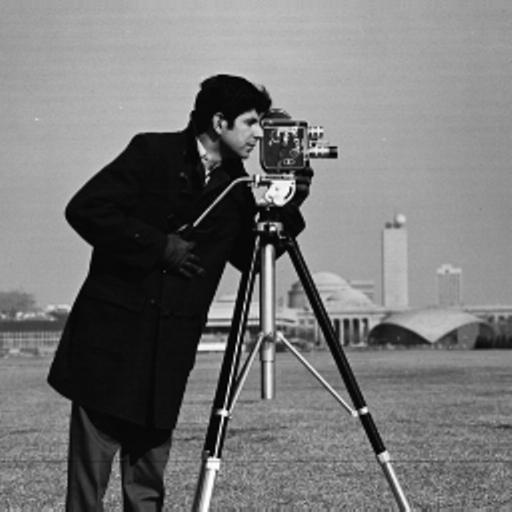

In [23]:
# ── Load image ───────────────────────────────────────
# Change the filename to your own image if needed.
img= Image.open("input_image.jpg.jpeg").convert("L")
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [24]:
# Get the size of the image
w, h = img.size          # PIL returns (width, height)
print("Original size (w, h):", (w, h))

# scaling factors
cx, cy = 2, 2            # double along both axes

Original size (w, h): (512, 512)


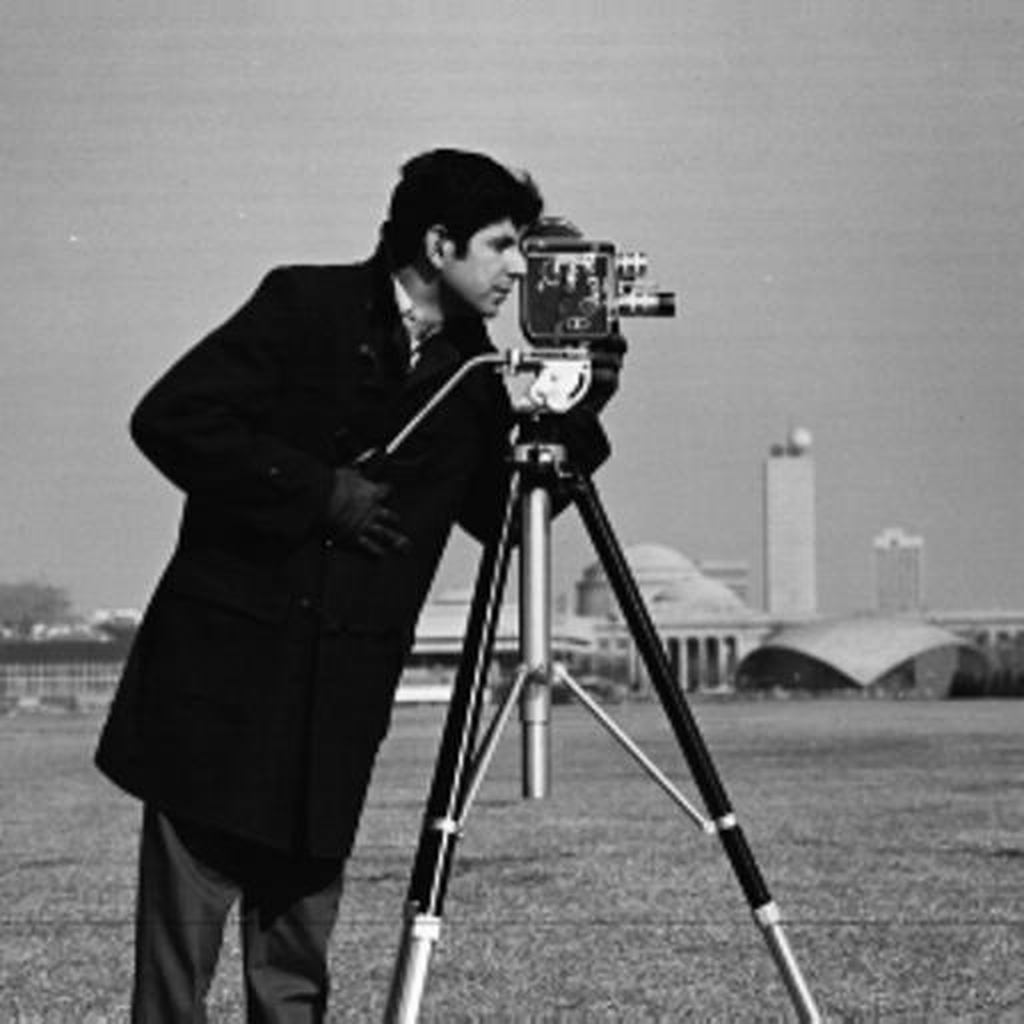

In [4]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
new_size = (w * cx, h * cy)
scaled = img.resize(new_size, Image.LANCZOS)   # high-quality resampling
scaled


In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled.save("task1_1_scaled.jpg")
print("Original size:", img.size)
print("Scaled size:  ", scaled.size)


Original size: (512, 512)
Scaled size:   (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [6]:
# Non-uniform scale (cx=2, cy=1) -> stretch horizontally only
cx, cy = 2, 1
stretch_size = (w * cx, h * cy)
print("Target size:", stretch_size)


Target size: (1024, 512)


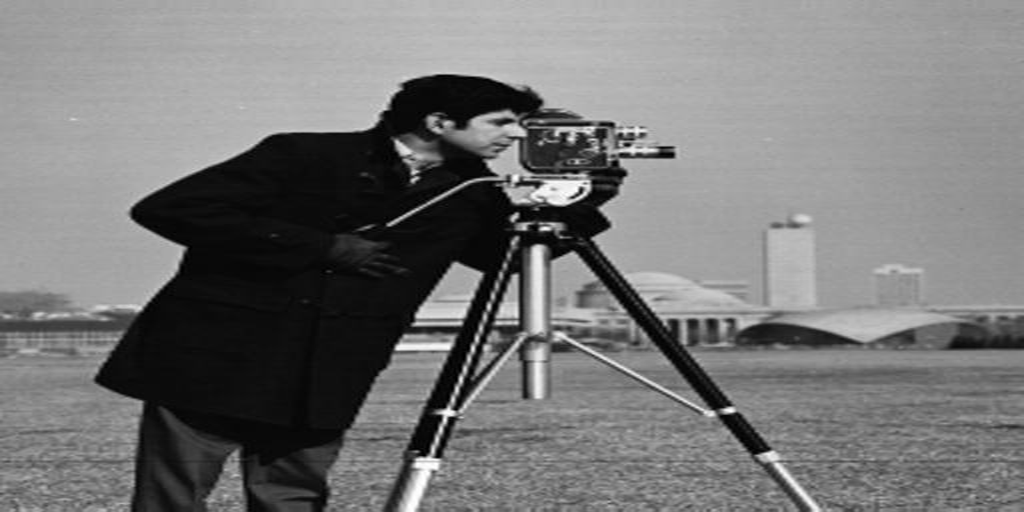

In [7]:
# Apply the non-uniform resize
stretched = img.resize(stretch_size, Image.LANCZOS)
stretched


In [8]:
# Save the horizontally-stretched image
stretched.save("task1_1_stretched.jpg")
print("Original size:  ", img.size)
print("Stretched size: ", stretched.size)


Original size:   (512, 512)
Stretched size:  (1024, 512)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (512, 512)
Rotated size:  (700, 700)


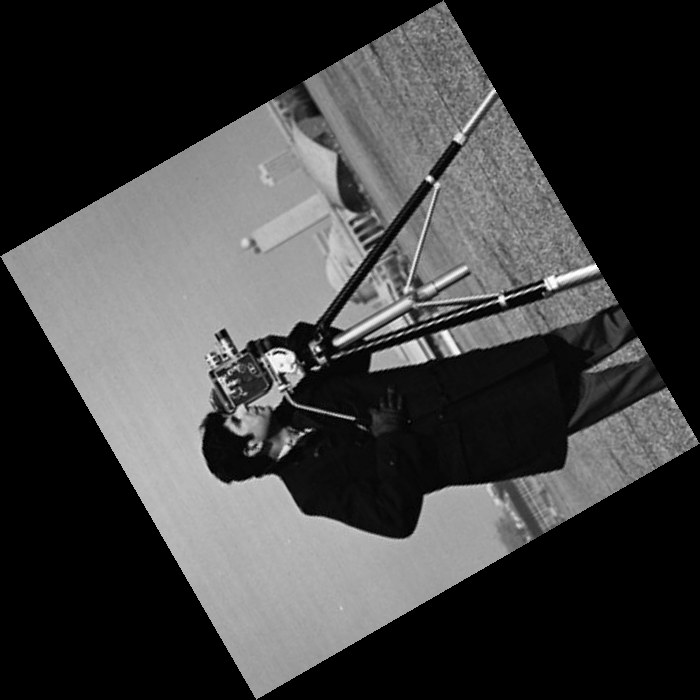

In [9]:
# ── 2. Rotate 120 degrees ──────────────────────
# Save the rotated image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated = img.rotate(
    120,                 
    expand=True,         
    resample=Image.BICUBIC,
    fillcolor=0,         
)
rotated.save("task1_2_rotated.jpg")
print("Original size:", img.size)
print("Rotated size: ", rotated.size)
rotated


### 3. Shear

In [10]:
# -- c. Get the image dimensions ──────────────────
width, height = img.size
print("Width, Height:", width, height)


Width, Height: 512 512


In [11]:
# -- d. define the shear matrix ─────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much
shear_factor = 0.5

shx = shear_factor
shy = 0.0


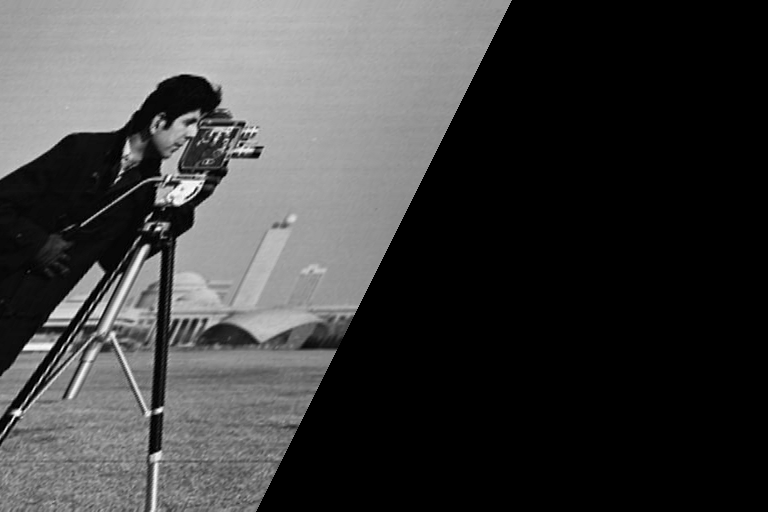

In [12]:
# -- e. Apply the shear transformation to the image ────────────────
# PIL's transform() takes the INVERSE affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

new_width  = width  + int(abs(shx) * height)
new_height = height + int(abs(shy) * width)

tx = -shx * height if shx < 0 else 0.0
ty = -shy * width  if shy < 0 else 0.0

coeffs = (1, shx, tx,
          shy, 1, ty)

sheared = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    coeffs,
    resample=Image.BICUBIC,
    fillcolor=0,
)
sheared


In [13]:
# -- f. Save the sheared image (The new image name should be "task1_3_sheared.jpg")
sheared.save("task1_3_sheared.jpg")
print("Original size:", img.size)
print("Sheared size: ", sheared.size)


Original size: (512, 512)
Sheared size:  (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

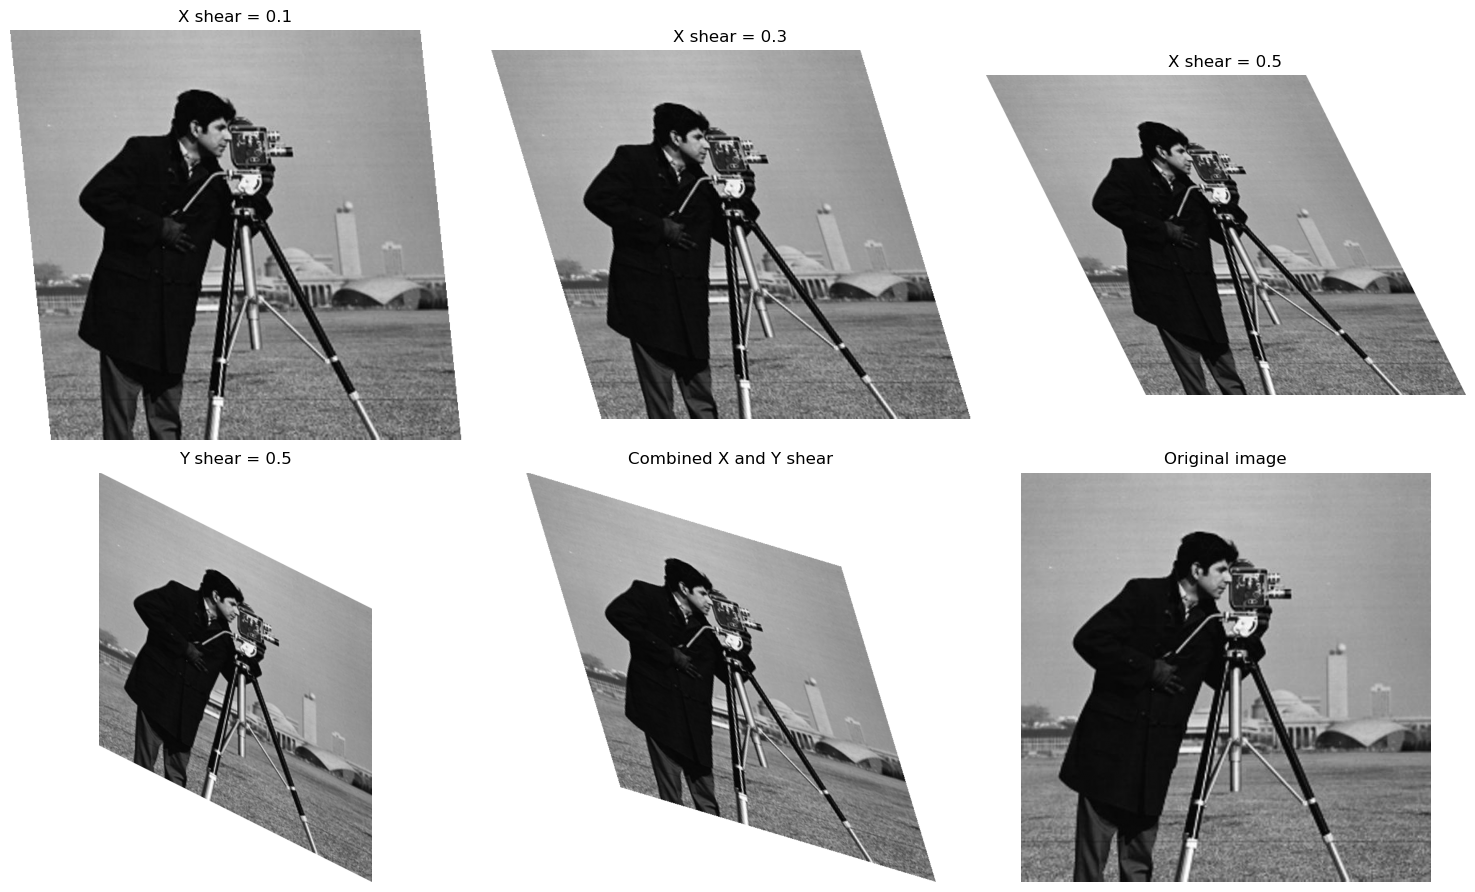

In [26]:
# ── Experiment and compare different shear transformations ──

import matplotlib.pyplot as plt
import numpy as np

width, height = img.size
shear_factors = [0.1, 0.3, 0.5, 0.8]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# 1. Compare different X-axis shear factors
for factor, ax in zip(shear_factors, axes[0]):
    new_width = int(np.ceil(width + factor * height))

    x_sheared = img.transform(
        (new_width, height),
        Image.Transform.AFFINE,
        (1, -factor, 0,
         0, 1, 0),
        resample=Image.Resampling.BICUBIC,
        fillcolor=255
    )

    ax.imshow(x_sheared, cmap="gray")
    ax.set_title(f"X shear = {factor}")
    ax.axis("off")

# 2. Y-axis shear
factor_y = 0.5
new_height = int(np.ceil(height + factor_y * width))

y_sheared = img.transform(
    (width, new_height),
    Image.Transform.AFFINE,
    (1, 0, 0,
     -factor_y, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=255
)

axes[1, 0].imshow(y_sheared, cmap="gray")
axes[1, 0].set_title("Y shear = 0.5")
axes[1, 0].axis("off")

# 3. Combined X-axis and Y-axis shear
shear_x = 0.3
shear_y = 0.3

new_width = int(np.ceil(width + shear_x * height))
new_height = int(np.ceil(height + shear_y * width))

# Inverse of the combined shear matrix
determinant = 1 - shear_x * shear_y

combined_matrix = (
    1 / determinant,
    -shear_x / determinant,
    0,
    -shear_y / determinant,
    1 / determinant,
    0
)

combined_sheared = img.transform(
    (new_width, new_height),
    Image.Transform.AFFINE,
    combined_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=255
)

axes[1, 1].imshow(combined_sheared, cmap="gray")
axes[1, 1].set_title("Combined X and Y shear")
axes[1, 1].axis("off")

# Original image for comparison
axes[1, 2].imshow(img, cmap="gray")
axes[1, 2].set_title("Original image")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

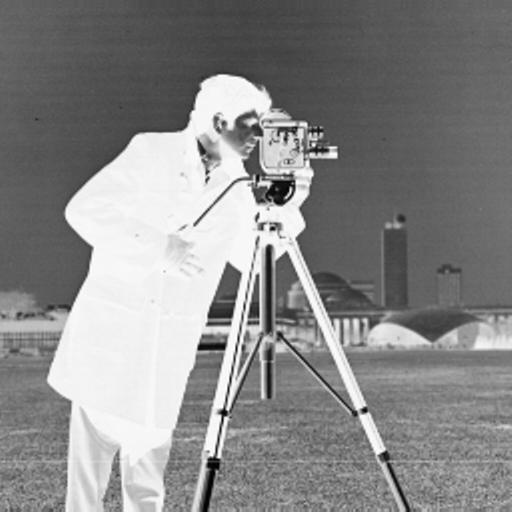

In [14]:

# ── 1. Negative ─────────────────────────────────────
# Method 1: NumPy array manipulation
arr = np.array(img)
negative_arr = 255 - arr
negative_img = Image.fromarray(negative_arr.astype(np.uint8))
negative_img.save("task2_1_negative_numpy.jpg")
negative_img


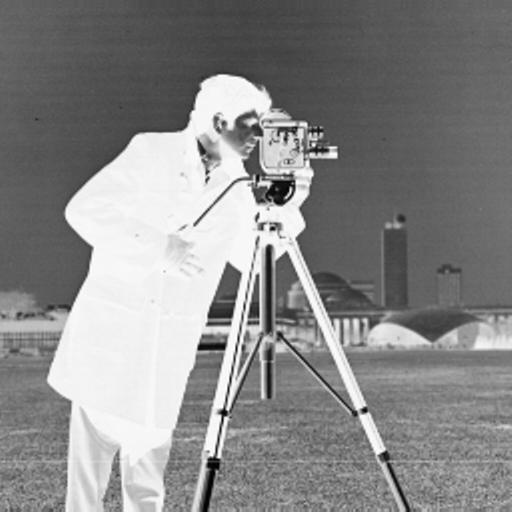

In [15]:
# Method 2: PIL's ImageOps
negative_img2 = ImageOps.invert(img)
negative_img2.save("task2_1_negative_imageops.jpg")
negative_img2


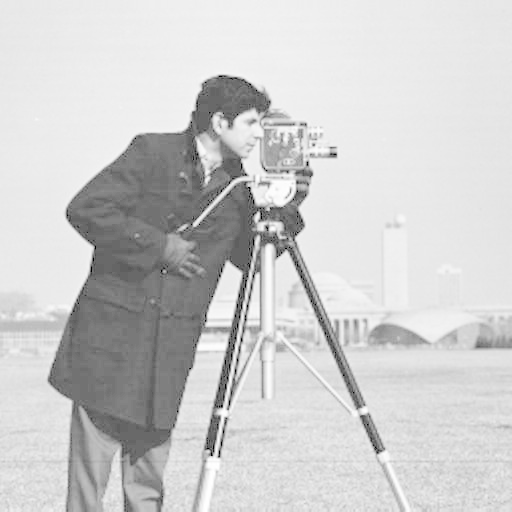

In [16]:
# ── 2. Log transformation ──────────────────
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel.
# Cast to float FIRST: a uint8 array would overflow (1 + 255 -> 0) and log(0) = -inf.
arr = np.array(img).astype(np.float64)
log_transformed_arr = c * np.log(1 + arr)
log_img = Image.fromarray(np.uint8(log_transformed_arr))
log_img.save("task2_2_log.jpg")
log_img


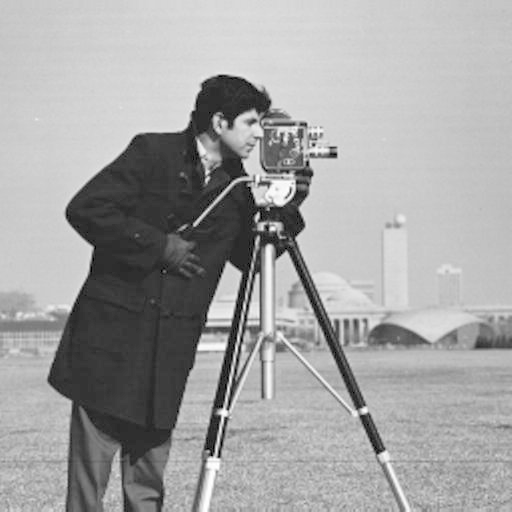

In [17]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

arr = np.array(img).astype(np.float64)
c = 255 / (255 ** gamma)                 # scale so the output stays in [0, 255]
gamma_arr = c * (arr ** gamma)
gamma_img = Image.fromarray(np.uint8(np.clip(gamma_arr, 0, 255)))
gamma_img.save("task2_3_gamma.jpg")
gamma_img


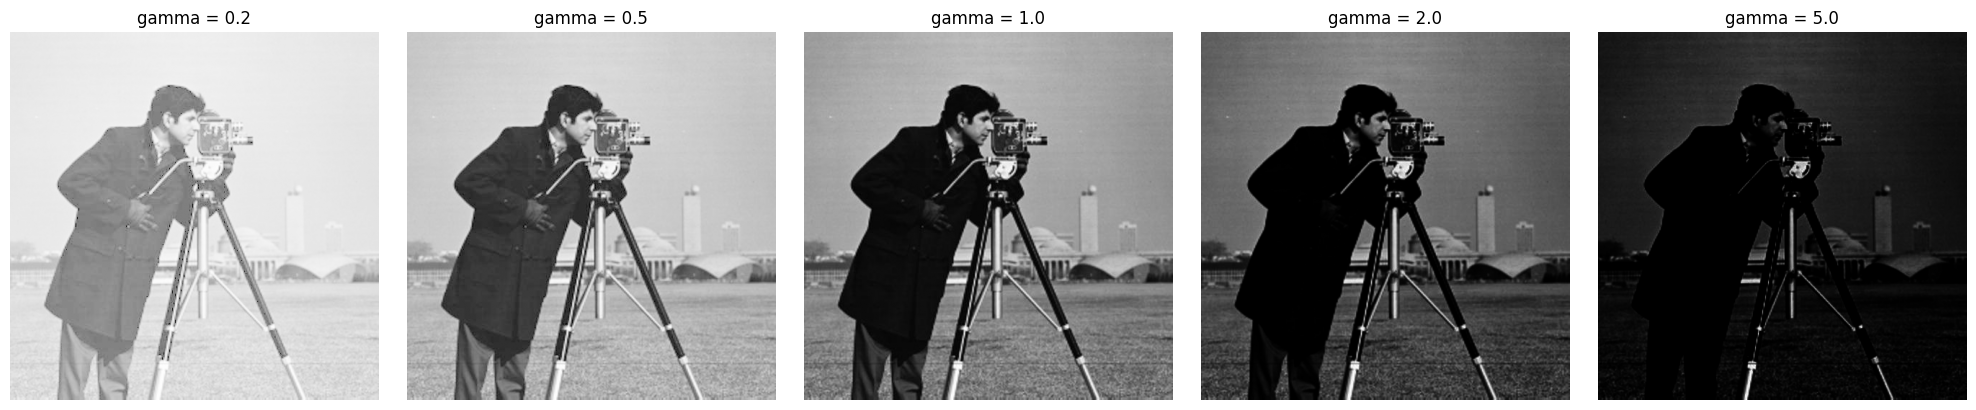

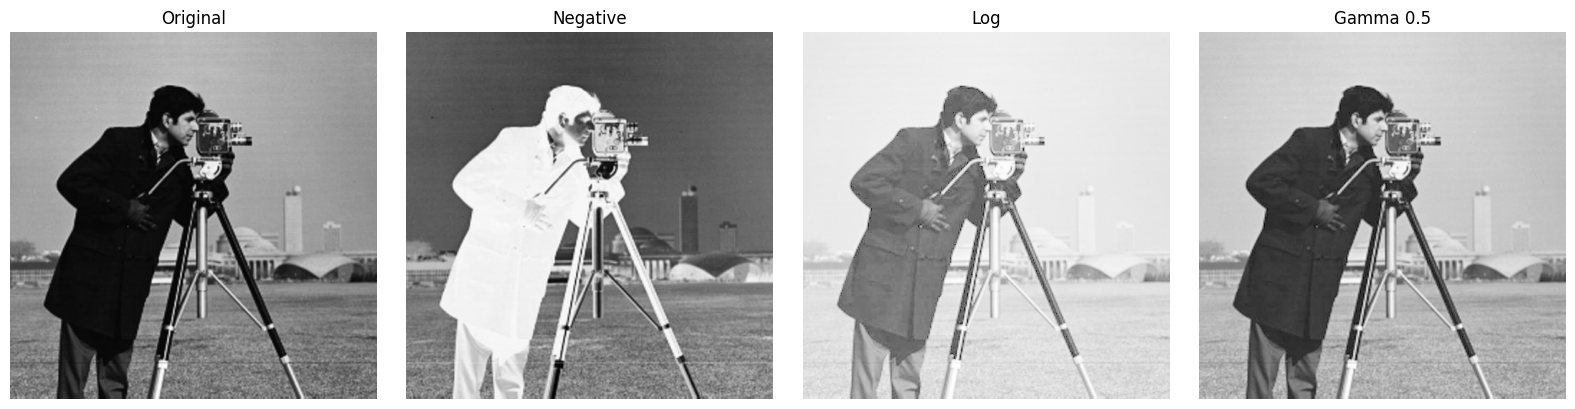

In [18]:
# ── Experiment & compare: several gamma values side by side ────
arr = np.array(img).astype(np.float64)

gammas = [0.2, 0.5, 1.0, 2.0, 5.0]
fig, axes = plt.subplots(1, len(gammas), figsize=(4 * len(gammas), 4))
for ax, g in zip(axes, gammas):
    c = 255 / (255 ** g)
    out = np.clip(c * (arr ** g), 0, 255).astype(np.uint8)
    ax.imshow(out, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"gamma = {g}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Overview of all intensity transforms
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, im) in zip(
    axes,
    [("Original", img),
     ("Negative", negative_img),
     ("Log", log_img),
     ("Gamma 0.5", gamma_img)],
):
    ax.imshow(np.array(im), cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()
